# EDA Agrupación por Macrogrupos

En este notebook se realizara un analisis exploratorio despues de las agrupaciones y de la limpeza de los datos a ver como se organizan los nuevos generos. En esta agrupación titulada **Macrogrupos** en esta si tiene otro enfoque en el cual se agrupan generos similares entre si.

| Grupo Resultante | Géneros Incluidos                                         | Justificación                                                                       |
|------------------|-----------------------------------------------------------|-------------------------------------------------------------------------------------|
| mainstream       | Pop, Dance, Rock, Alternative, Indie, R&B, Soul           | Música con alta rotación comercial y estructuras de producción similares.           |
| urban            | Hip-Hop, Rap, Reggaeton, Reggae, Ska                      | Géneros basados en ritmos síncopados, fuerte presencia de bajo y raíces callejeras. |
| acoustic         | Classical, Opera, Jazz, Blues, Folk, Country              | Música con mayor énfasis en instrumentos orgánicos y teoría musical tradicional.    |
| other            | Electronic, Soundtrack, Movie, Anime, Kids, World, Comedy | Contenido funcional, temático o que no encaja en las texturas anteriores.           |

In [6]:
import sys
import os
import importlib
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import src.features.preprocessing_4classes as prep
importlib.reload(prep) 
df, x, y = prep.preprocessing()

df.head(5)

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,es_muy_larga,genre_grouped_4
0,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814,False,other
1,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816,False,other
2,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368,False,other
3,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227,False,other
4,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390,False,other


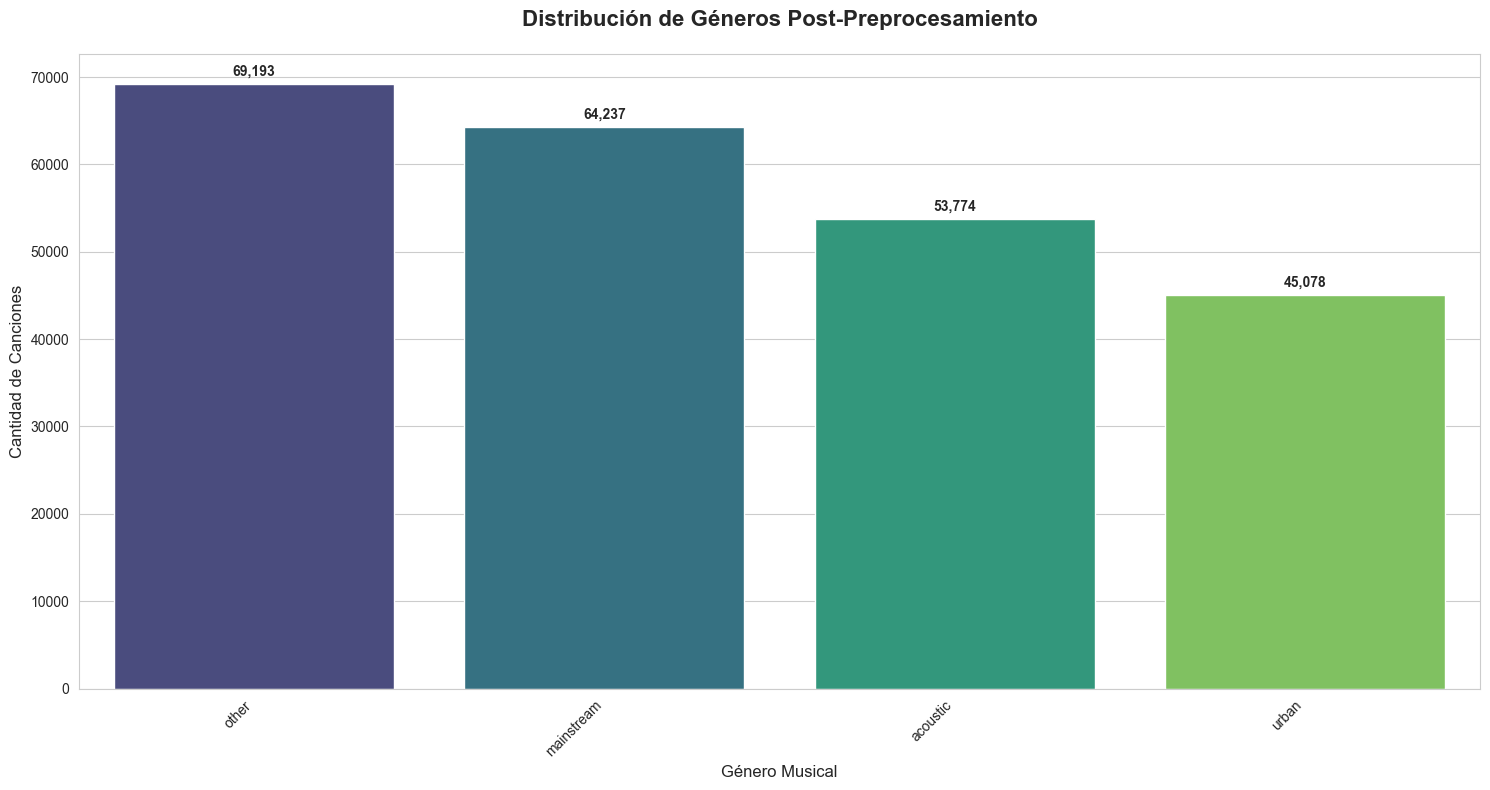

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_counts = df['genre_grouped_4'].value_counts()

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

ax = sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')
    
plt.title('Distribución de Géneros Post-Preprocesamiento', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Género Musical', fontsize=12)
plt.ylabel('Cantidad de Canciones', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [8]:
stats_despues = {
    'Num. Clases': df['genre_grouped_4'].nunique(),
    'Mínimo muestras': df['genre_grouped_4'].value_counts().min(),
    'Máximo muestras': df['genre_grouped_4'].value_counts().max(),
    'Promedio por clase': df['genre_grouped_4'].value_counts().mean()
}

stats_despues

{'Num. Clases': 4,
 'Mínimo muestras': 45078,
 'Máximo muestras': 69193,
 'Promedio por clase': 58070.5}

EDA Agrupación por Macrogrupos
En este eda una vez realizada la limpieza de datos se creo la agrupacion de los generos musicales llamada Macrogrupos, dando de resuktado 4 grupos diferentes, en base a los stats_despues, se evidencia un desbalanceo entre los datos pero no es muy pronunciado, pero de todas formas se realizaran un balanceo para que esto no afecte el modelo predictor

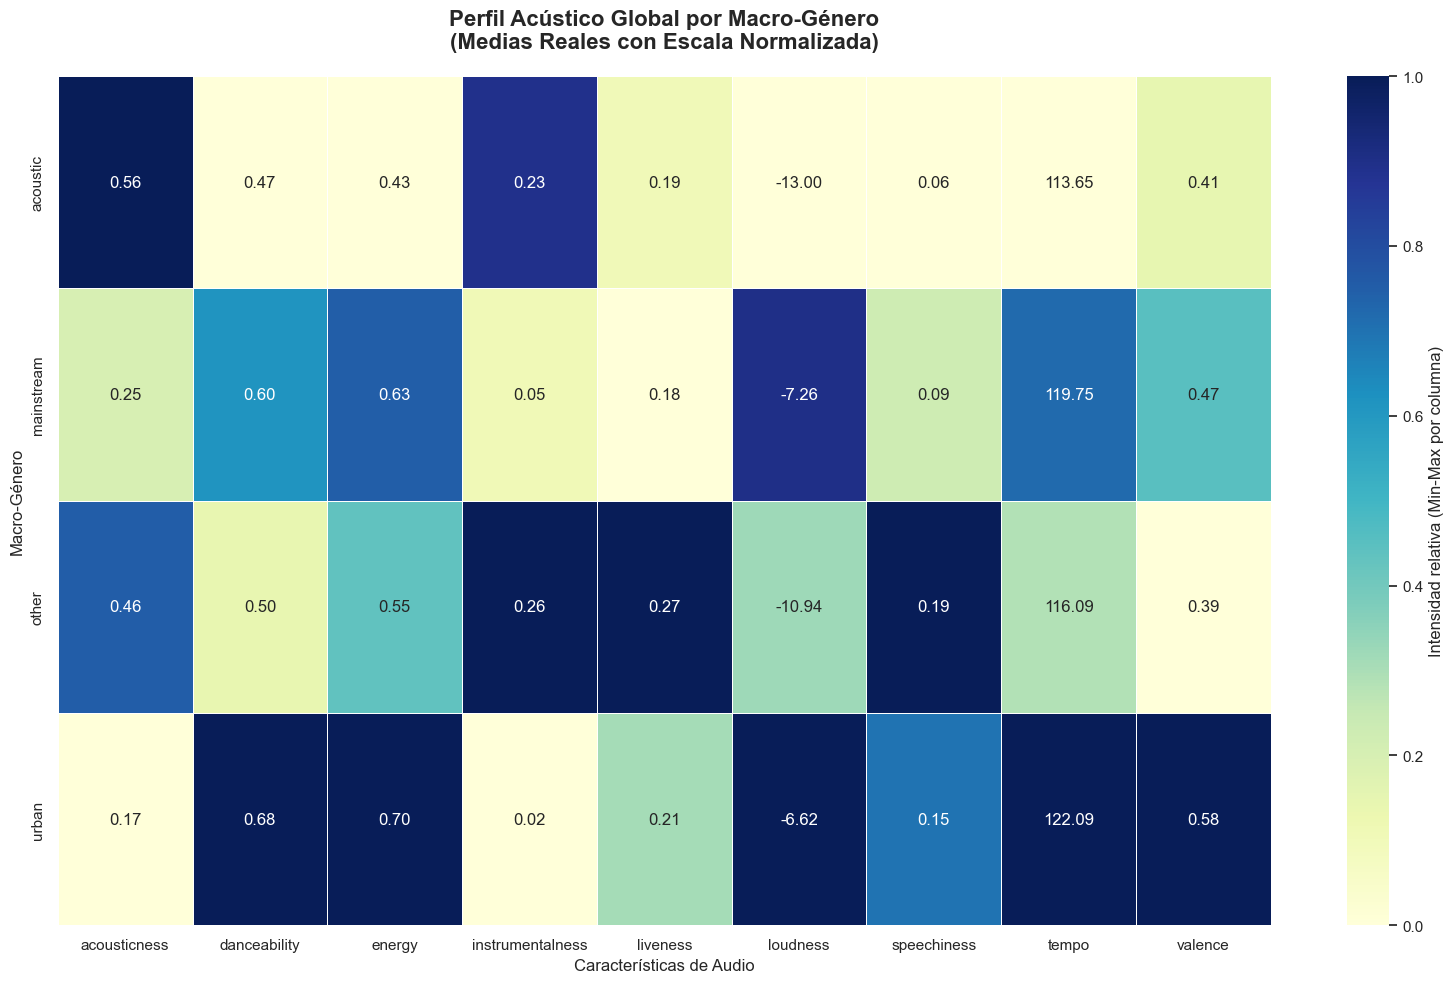

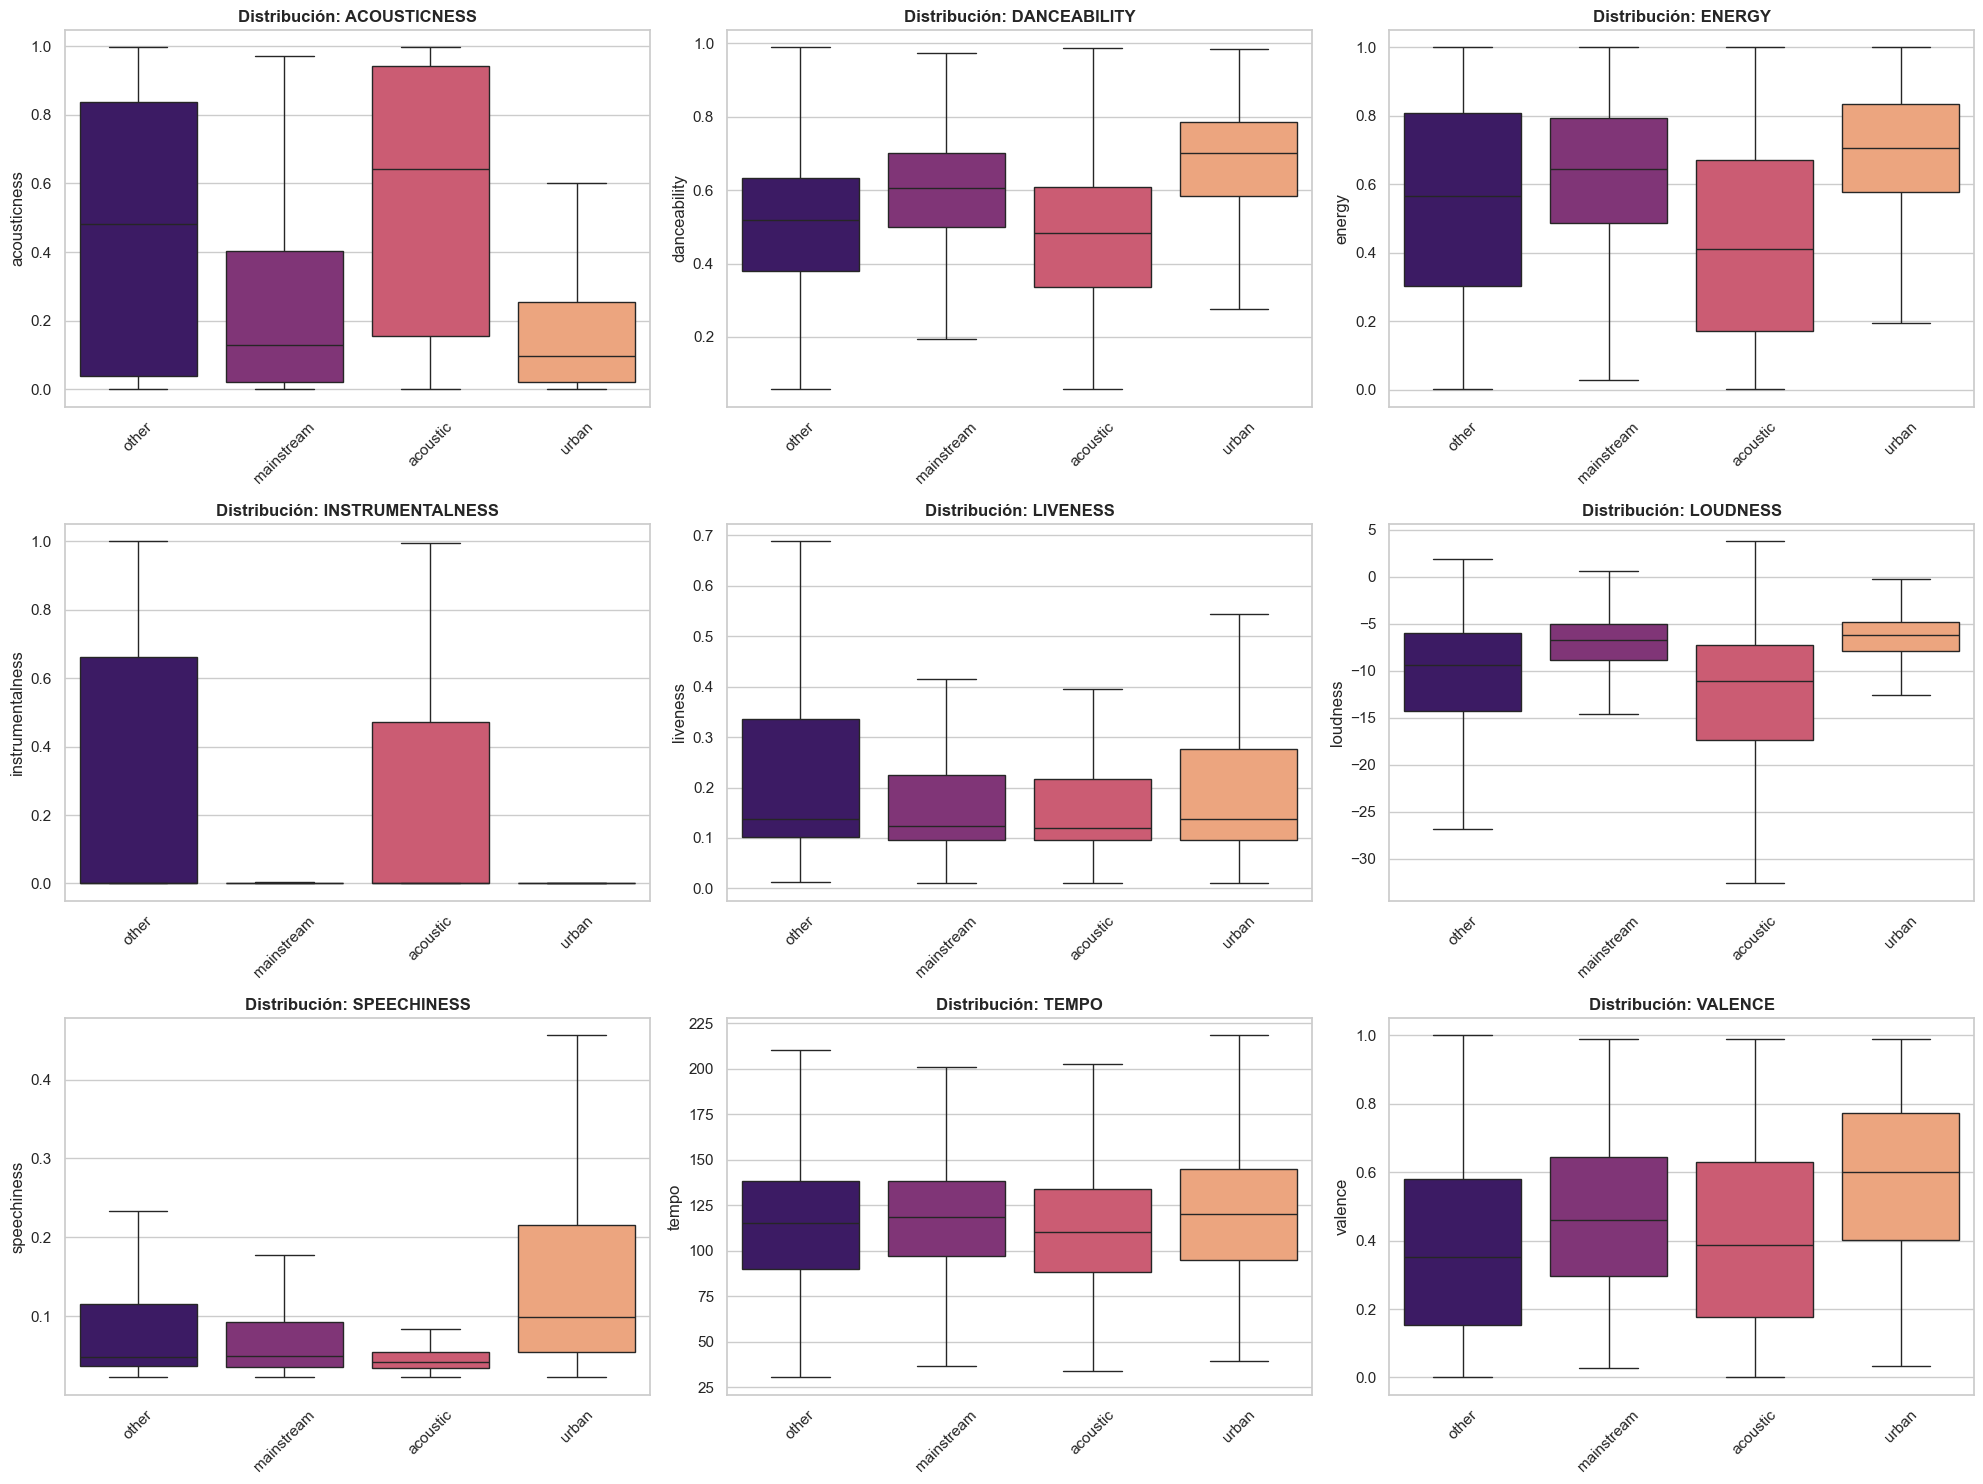

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid", palette="pastel")

# -----------------------------
# Selección de columnas numéricas
# -----------------------------
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

cols_excluir = ['duration_ms', 'key', 'mode', 'time_signature', 'popularity']
cols_numericas = [col for col in cols_numericas if col not in cols_excluir]

# -----------------------------
# PERFIL PROMEDIO POR GÉNERO
# -----------------------------
perfil_medios = df.groupby('genre_grouped_4')[cols_numericas].mean()

# Normalización para heatmap (escala relativa)
perfil_norm = (perfil_medios - perfil_medios.min()) / (perfil_medios.max() - perfil_medios.min())

plt.figure(figsize=(16, 10))

sns.heatmap(
    perfil_norm,
    annot=perfil_medios.round(2),
    fmt=".2f",
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Intensidad relativa (Min-Max por columna)'}
)

plt.title(
    'Perfil Acústico Global por Macro-Género\n(Medias Reales con Escala Normalizada)',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.ylabel('Macro-Género', fontsize=12)
plt.xlabel('Características de Audio', fontsize=12)

plt.tight_layout()
plt.show()

# -----------------------------
# DESVIACIÓN ESTÁNDAR (DISPERSIÓN)
# -----------------------------
perfil_std = df.groupby('genre_grouped_4')[cols_numericas].std()

perfil_std.round(3)

# -----------------------------
# BOXPLOTS POR VARIABLE
# -----------------------------
n_cols = 3
n_rows = (len(cols_numericas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.boxplot(
        x='genre_grouped_4',
        y=col,
        data=df,
        ax=axes[i],
        palette='magma',
        showfliers=False
    )
    
    axes[i].set_title(f'Distribución: {col.upper()}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

# Eliminar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

| Macro-Grupo | Característica   | Valor | Fuerza (%) | Interpretación                          |
| ----------- | ---------------- | ----- | ---------- | --------------------------------------- |
| acoustic    | acousticness     | 0.56  | 56%        | Tendencia a sonido natural (media-alta) |
| mainstream  | energy           | 0.63  | 63%        | Música energética                       |
| mainstream  | danceability     | 0.60  | 60%        | Bailable                                |
| other       | instrumentalness | 0.26  | —          | No es fuerte (no destaca claramente)    |
| urban       | energy           | 0.70  | 70%        | Muy energético                          |
| urban       | danceability     | 0.68  | 68%        | Muy bailable                            |
| urban       | valence          | 0.58  | 58%        | Emoción positiva moderada               |

| Relación                  | Fuerza |
| ------------------------- | ------ |
| energy ↔️ urban            | 70%    |
| danceability ↔️ urban      | 68%    |
| energy ↔️ mainstream       | 63%    |
| danceability ↔️ mainstream | 60%    |

EN base a la tabla de correlacion entre Macro-Género y caracteristicas de audio los grupos como "urban" presentan una fuerte correlacion lineal con "energy" alcanzando un 70% de correlacion y "urban" con "danceabiolity" logrando un 68% queriendo decir que este ultimo es bastante bailable, ademas de esoson variables a tener en cuenta a la hora de de pasar los datos por el modelo ya que pueden ayudar al modelo predictor

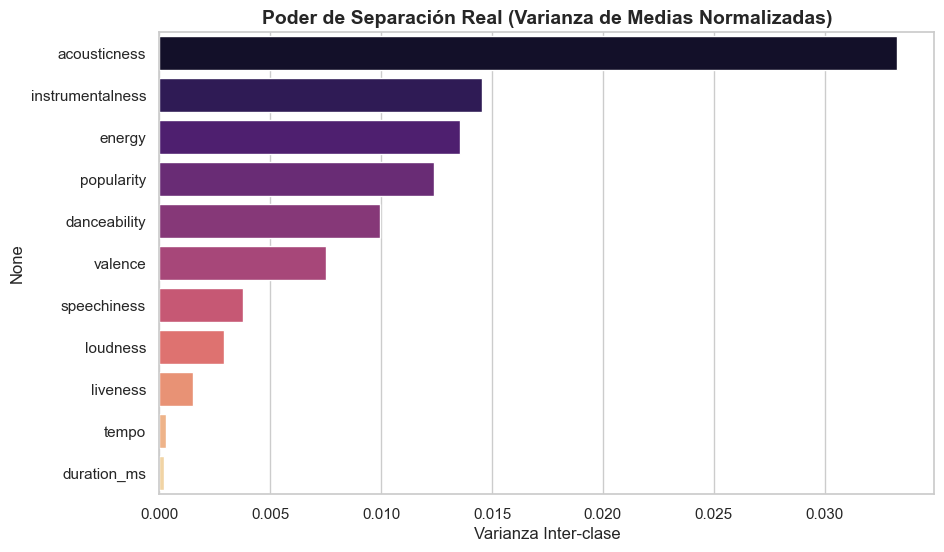

acousticness        0.033282
instrumentalness    0.014543
energy              0.013577
popularity          0.012367
danceability        0.009939
valence             0.007523
speechiness         0.003759
loudness            0.002916
liveness            0.001526
tempo               0.000312
duration_ms         0.000219
dtype: float64


In [12]:
from sklearn.preprocessing import MinMaxScaler


cols_cuantitativas = df.select_dtypes(include=[np.number]).columns.tolist()

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[cols_cuantitativas]), columns=cols_cuantitativas)
df_scaled['genre_grouped_4'] = df['genre_grouped_4'].values

ranking_separacion = df_scaled.groupby('genre_grouped_4').mean().var().sort_values(ascending=False)

# 4. Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x=ranking_separacion.values, y=ranking_separacion.index, palette='magma')
plt.title('Poder de Separación Real (Varianza de Medias Normalizadas)', fontsize=14, fontweight='bold')
plt.xlabel('Varianza Inter-clase')
plt.show()

print(ranking_separacion)

Analizando la varianza y medias presentados en las grafiicas de boxsplot separados por caracteristicas de audios, con el grupo de generos, se identifico que la variable "acousticness" tiene un poder discriminatorio particularmente alto siendo cpn respecto a los demas, teniendo una varianza de 0.033452 se consideran variables importantes al momento de utilizarlas en el modelo ya que estas pueden distinguir mejor entre los grupos de MACRO-GRUPOS

Conclucion
En este notebook se realizo un analisis exploratorio de esta agrupacion luego de realizar una limpieza de daros dando como resultado 4 agrupaciones, acontinuacion se presentaran los allazgos hallados:
* Presnta un desbalance no tan pronunciado pero aun considerable por lo tanto se debe hacer un balanceo antes de pasar los datos por el modelo predictivo
* A partir de las graficas del notebook se identificaron algunas variables con una fuerte correlacion lineal tal como "energy" con "urban" alcanzando una correlacion de hasta el 70%
* Se identifico una variable con un poder discriminatorio considertable frente a las demas variables siendo "acousticness", esta variable es capaz de distinguir entre los grupos mejor que las otras varuables por tanto es una variable a considerar para el modelo predictivo